# Install KaggleHUb

In [1]:
!pip install -q kagglehub

# Import Dataset

In [2]:
import kagglehub
data_path = kagglehub.dataset_download("devang03mgr/cattle-diseases-datasets")
print('Data source import complete.')
print('Dataset downloaded to:', data_path)

Data source import complete.
Dataset downloaded to: /kaggle/input/cattle-diseases-datasets


# Import Libraries 

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input, Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121, EfficientNetB0

2026-01-20 16:26:23.558784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768926384.011206      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768926384.127189      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768926385.273750      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768926385.273807      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768926385.273810      24 computation_placer.cc:177] computation placer alr

# Detect Correct Base Directory & List Classes

In [4]:
print("Contents of downloaded folder:")
print(os.listdir(data_path))

base_dir = data_path
items = os.listdir(data_path)
class_candidates = [item for item in items if os.path.isdir(os.path.join(data_path, item))]

if len(class_candidates) == 1:
    base_dir = os.path.join(data_path, class_candidates[0])
    print(f"\nUsing subfolder: {class_candidates[0]}")
elif 'Cows datasets' in class_candidates:
    base_dir = os.path.join(data_path, 'Cows datasets')
    print("\nFound 'Cows datasets' folder")

disease_types = sorted([d for d in os.listdir(base_dir)
                        if os.path.isdir(os.path.join(base_dir, d))])

print("\nDisease Classes Found:")
for i, disease in enumerate(disease_types):
    count = len([f for f in os.listdir(os.path.join(base_dir, disease))
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"{i}: {disease} ({count} images)")

num_classes = len(disease_types)
print(f"\nTotal classes: {num_classes}")

Contents of downloaded folder:
['Cows datasets']

Using subfolder: Cows datasets

Disease Classes Found:
0: foot-and-mouth (746 images)
1: healthy (1291 images)
2: lumpy (1207 images)

Total classes: 3


# Create DataFrame with File Paths and Labels

In [5]:
train_data = []

for disease_id, disease in enumerate(disease_types):
    disease_folder = os.path.join(base_dir, disease)
    for file in os.listdir(disease_folder):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            train_data.append([f"{disease}/{file}", disease_id, disease])

train = pd.DataFrame(train_data, columns=['File', 'DiseaseID', 'Disease Type'])
train = train.sample(frac=1, random_state=42).reset_index(drop=True)

print("Sample entries:")
train.head()

Sample entries:


,File,DiseaseID,Disease Type
0,lumpy/Lumpy_Skin_137-resized.jpg,2,lumpy
1,lumpy/IMG_20220829_124626_jpg.rf.11448e88fa8f0...,2,lumpy
2,healthy/imgs278(1).jpg,1,healthy
3,foot-and-mouth/Diseased-dental-pad-21_jpg.rf.2...,0,foot-and-mouth
4,lumpy/img1021.jpg,2,lumpy


# Visualize Class Distribution

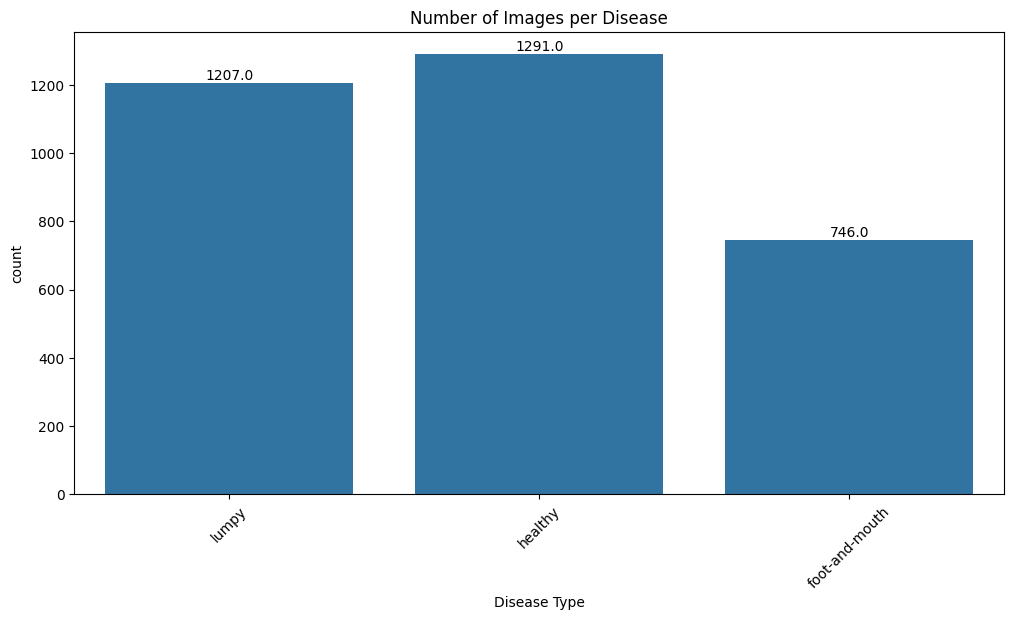

Total images: 3244


In [6]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=train, x='Disease Type')
plt.title('Number of Images per Disease')
plt.xticks(rotation=45)

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

print("Total images:", len(train))

# Display Sample Images from One Class

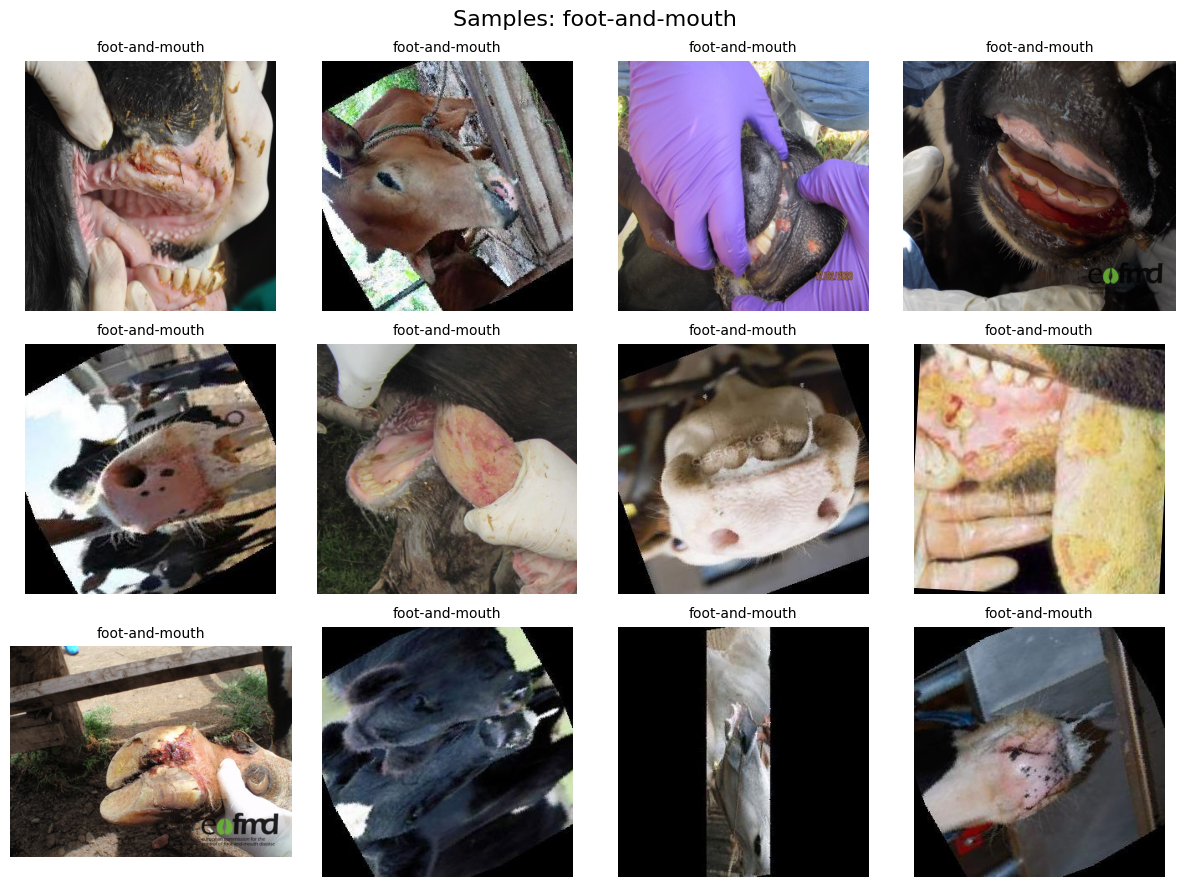

In [7]:
def plot_samples(disease_name, rows=3, cols=4):
    fig, axes = plt.subplots(rows, cols, figsize=(12, 9))
    files = train[train['Disease Type'] == disease_name]['File'].values[:rows*cols]
    for i, ax in enumerate(axes.flat):
        if i < len(files):
            img_path = os.path.join(base_dir, files[i])  # ← Fixed: use base_dir
            img = cv2.imread(img_path)
            if img is None:
                ax.text(0.5, 0.5, 'Failed to load', ha='center', va='center')
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            ax.axis('off')
            ax.set_title(disease_name, fontsize=10)
        else:
            ax.axis('off')
    plt.suptitle(f"Samples: {disease_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Now run it safely
if len(disease_types) > 0:
    plot_samples(disease_types[0])
else:
    print("No classes found!")

# Load, Resize & Normalize Images

In [8]:
IMAGE_SIZE = 224

def read_image(filepath):
    full_path = os.path.join(base_dir, filepath)
    img = cv2.imread(full_path)
    if img is None:
        print(f"Warning: Failed to load {full_path}")
    return img

def resize_image(image, size):
    if image is None:
        return None
    return cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA)

X = np.zeros((len(train), IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32)
failed_count = 0

print("Loading and resizing images...")
for i, file in tqdm(enumerate(train['File'].values), total=len(train)):
    image = read_image(file)
    if image is not None:
        resized = resize_image(image, IMAGE_SIZE)
        if resized is not None:
            X[i] = resized
    else:
        failed_count += 1

if failed_count > 0:
    print(f"\nWarning: {failed_count} images failed to load.")

# First: /255.0 normalization
X = X / 255.0

print(f"Shape after loading: {X.shape}")

Loading and resizing images...


100%|██████████| 3244/3244 [01:19<00:00, 40.98it/s]


Shape after loading: (3244, 224, 224, 3)


# Stratified Split + ImageNet Normalization


In [9]:
from sklearn.model_selection import train_test_split

Y = to_categorical(train['DiseaseID'].values, num_classes=num_classes)

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42, stratify=Y_temp)

print("Stratified Split Completed")
print(f"   Training:   {len(X_train):,} images")
print(f"   Validation: {len(X_val):,} images")
print(f"   Test:       {len(X_test):,} images")

# === FIX: Apply ImageNet mean/std normalization ===
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print("Applied ImageNet mean/std normalization")

Stratified Split Completed
   Training:   2,270 images
   Validation: 487 images
   Test:       487 images
Applied ImageNet mean/std normalization


In [10]:
# Cell 9: Safer Capped Class Weights (FIXED)
class_weights_raw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train['DiseaseID']),
    y=train['DiseaseID']
)

max_weight = 10.0
class_weights = np.minimum(class_weights_raw, max_weight)
class_weight_dict = dict(enumerate(class_weights))

print("SAFE Class Weights (capped at 10x):")
print("="*60)
for i, w in enumerate(class_weights):
    raw = class_weights_raw[i]
    print(f"   {disease_types[i]:<30}: raw={raw:.1f}x → capped={w:.2f}x")
print("="*60)

SAFE Class Weights (capped at 10x):
   foot-and-mouth                : raw=1.4x → capped=1.45x
   healthy                       : raw=0.8x → capped=0.84x
   lumpy                         : raw=0.9x → capped=0.90x


# Build DenseNet121 Model

In [11]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_densenet():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    input = Input(shape=(224, 224, 3))
    x = base_model(input)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(input, output)
    model.compile(optimizer=Adam(learning_rate=0.0003),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()
    return model
densenet_model = build_densenet()

I0000 00:00:1768926493.877157      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768926493.880975      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,795 (27.87 MB)

 Trainable params: 7,219,587 (27.54 MB)

 Non-trainable params: 86,208 (336.75 KB)

# Train DenseNet121

In [12]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

BATCH_SIZE = 32
EPOCHS = 30

# Mild augmentation
datagen_densenet = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)
datagen_densenet.fit(X_train)

# Best save by val_loss + early stopping
checkpoint = ModelCheckpoint(
    'best_densenet_cattle.keras',
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("🚀 Starting DenseNet121 training...")
print("   • Model: densenet_model")
print("   • Saving best by val_loss")
print("   • Early stopping enabled\n")

densenet_history = densenet_model.fit(
    datagen_densenet.flow(X_train, Y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

🚀 Starting DenseNet121 training...
   • Model: densenet_model
   • Saving best by val_loss
   • Early stopping enabled

Epoch 1/30


I0000 00:00:1768926559.110410      81 service.cc:152] XLA service 0x7cd59c009770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768926559.110457      81 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768926559.110462      81 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768926569.894355      81 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1768926674.709160      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6482 - loss: 0.9974
Epoch 1: val_loss improved from inf to 0.49545, saving model to best_densenet_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.6495 - loss: 0.9938 - val_accuracy: 0.8152 - val_loss: 0.4954 - learning_rate: 3.0000e-04
Epoch 2/30
 1/70 ━━━━━━━━━━━━━━━━━━━━ 24s 359ms/step - accuracy: 0.8125 - loss: 0.5893
Epoch 2: val_loss did not improve from 0.49545
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8125 - loss: 0.5893 - val_accuracy: 0.8049 - val_loss: 0.4994 - learning_rate: 3.0000e-04
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8456 - loss: 0.3976
Epoch 3: val_loss improved from 0.49545 to 0.46871, saving model to best_densenet_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 437ms/step - accuracy: 0.8458 - loss: 0.3975 - val_accuracy: 0.8706 - val_loss: 0.4687 - learning_rate: 3.0000e-04
Epoch 4/30
 1/70 ━━━━━━━━━━━━━━━━━━━━ 23s 343ms/step - accuracy: 0.8125 - loss: 0.3461
E

# Results

In [13]:
# SAVE RESULTS TO CSV - KEEPING YOUR ORIGINAL LOGIC

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import os

# CHANGE THESE FOR EACH MODEL
model_name = "DenseNet121"
history_obj = densenet_history
# Load the best saved model
best_model = load_model('best_densenet_cattle.keras')

# Evaluate the CORRECT model on test set
test_loss, test_acc = best_model.evaluate(X_test, Y_test, verbose=0)

# Predictions using the same model
Y_pred = best_model.predict(X_test, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Classification metrics
report = classification_report(Y_true, Y_pred_classes, output_dict=True, digits=4)
macro_f1 = report['macro avg']['f1-score']

# Macro AUC
y_test_bin = label_binarize(Y_true, classes=range(num_classes))
macro_auc = np.mean([auc(*roc_curve(y_test_bin[:, i], Y_pred[:, i])[:2]) for i in range(num_classes)])

# Epoch-wise data
epochs_data = []
for epoch in range(len(history_obj.history['loss'])):
    epochs_data.append({
        'Model': model_name,
        'Epoch': epoch + 1,
        'Train_Accuracy': round(history_obj.history['accuracy'][epoch], 4),
        'Train_Loss': round(history_obj.history['loss'][epoch], 4),
        'Val_Accuracy': round(history_obj.history['val_accuracy'][epoch], 4),
        'Val_Loss': round(history_obj.history['val_loss'][epoch], 4)
    })

# Final test results row
final_row = {
    'Model': model_name,
    'Epoch': 'FINAL',
    'Train_Accuracy': round(np.max(history_obj.history['accuracy']), 4),
    'Train_Loss': round(np.min(history_obj.history['loss']), 4),
    'Val_Accuracy': round(np.max(history_obj.history['val_accuracy']), 4),
    'Val_Loss': round(np.min(history_obj.history['val_loss']), 4),
    'Test_Accuracy': round(test_acc * 100, 2),
    'Test_Loss': round(test_loss, 4),
    'Macro_F1': round(macro_f1, 4),
    'Macro_AUC': round(macro_auc, 4)
}

# Save to CSV (append if exists)
csv_file = 'cattle_disease_all_models_results.csv'

if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_epochs = pd.DataFrame(epochs_data)
    df_final = pd.DataFrame([final_row])
    df_new = pd.concat([df_existing, df_epochs, df_final], ignore_index=True)
else:
    df_new = pd.DataFrame(epochs_data + [final_row])

df_new.to_csv(csv_file, index=False)

print(f"✅ Results CORRECTLY saved to {csv_file}")
print(f"   Model: {model_name}")
print(f"   Best Val Accuracy: {np.max(history_obj.history['val_accuracy'])*100:.2f}%")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Macro F1: {macro_f1:.4f} | Macro AUC: {macro_auc:.4f}")

✅ Results CORRECTLY saved to cattle_disease_all_models_results.csv
   Model: DenseNet121
   Best Val Accuracy: 95.07%
   Test Accuracy: 94.46%
   Macro F1: 0.9480 | Macro AUC: 0.9912


# Model Evaluation

DENSENET121 BEST MODEL LOADED
Test Accuracy : 0.9446 (94.46%)
Test Loss : 0.1822
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 902ms/step

PER-CLASS METRICS (Precision | Recall | F1)
                precision    recall  f1-score   support

foot-and-mouth     0.9649    0.9821    0.9735       112
       healthy     0.9130    0.9742    0.9426       194
         lumpy     0.9699    0.8895    0.9280       181

      accuracy                         0.9446       487
     macro avg     0.9493    0.9486    0.9480       487
  weighted avg     0.9461    0.9446    0.9443       487



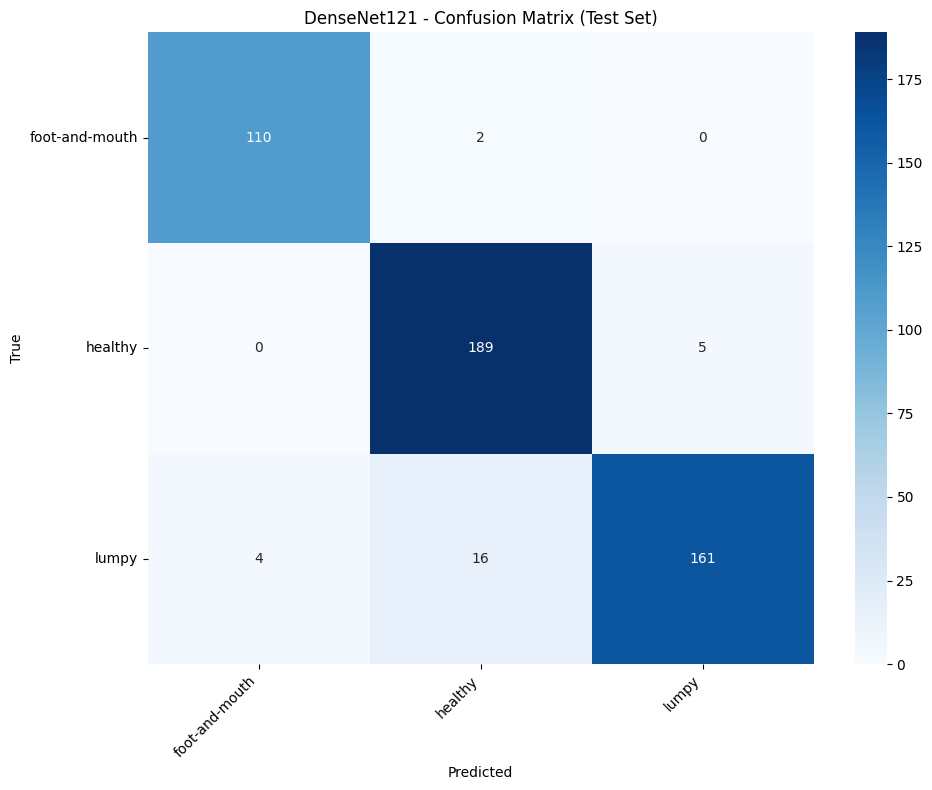

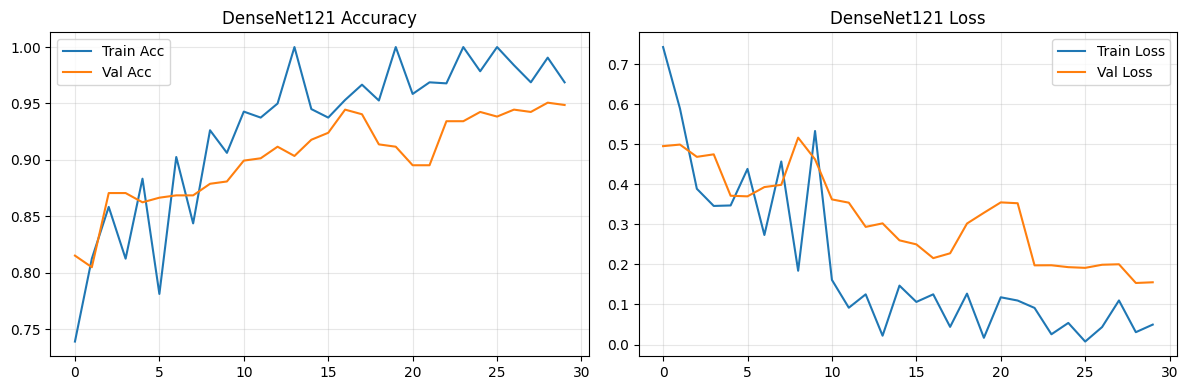


AUC SCORES
Micro-average AUC: 0.9917
foot-and-mouth: 0.9938
healthy: 0.9890
lumpy: 0.9909


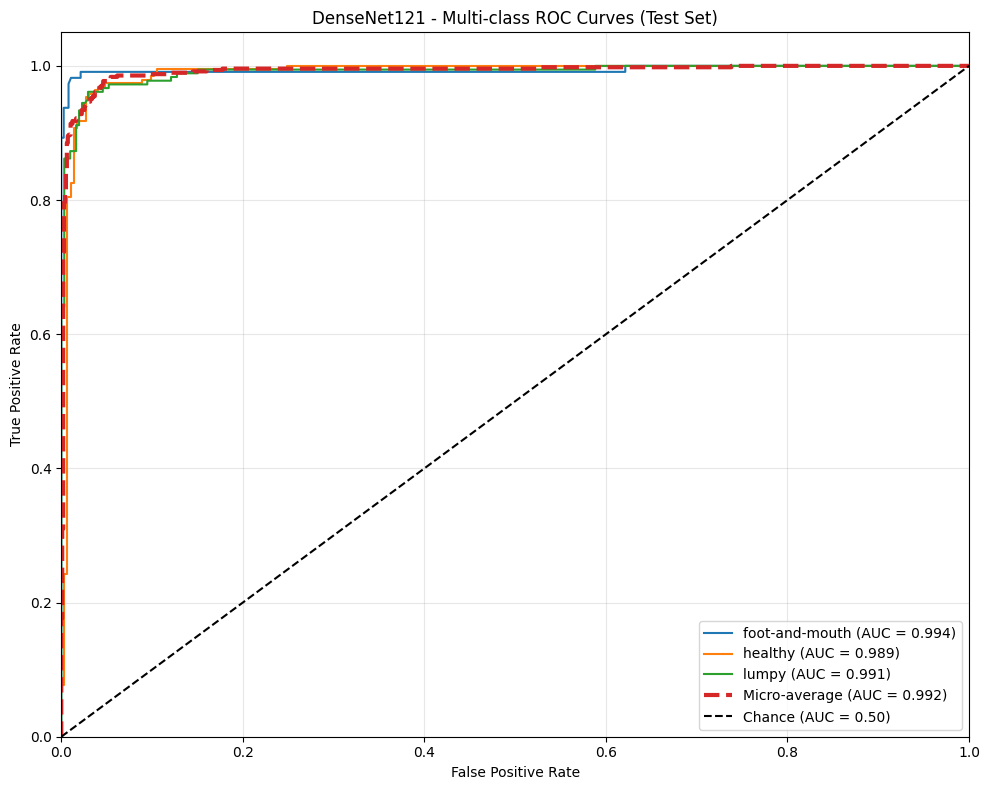


DenseNet121 evaluation complete!


In [14]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np

# Load best DenseNet121 model
densenet_best = load_model('best_densenet_cattle.keras')
print("DENSENET121 BEST MODEL LOADED")
print("="*70)

# Test evaluation
test_loss, test_acc = densenet_best.evaluate(X_test, Y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss : {test_loss:.4f}")

# Predictions
Y_pred = densenet_best.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Per-class report
print("\n" + "="*60)
print("PER-CLASS METRICS (Precision | Recall | F1)")
print("="*60)
print(classification_report(Y_true, Y_pred_classes, target_names=disease_types, digits=4))

# Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(Y_true, Y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_types, yticklabels=disease_types)
plt.title('DenseNet121 - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training Curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(densenet_history.history['accuracy'], label='Train Acc')
plt.plot(densenet_history.history['val_accuracy'], label='Val Acc')
plt.title('DenseNet121 Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(densenet_history.history['loss'], label='Train Loss')
plt.plot(densenet_history.history['val_loss'], label='Val Loss')
plt.title('DenseNet121 Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# === ADDED: AUC and ROC Curves ===
n_classes = len(disease_types)

# Binarize the true labels for multi-class ROC
Y_test_bin = label_binarize(Y_true, classes=range(n_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(Y_test_bin.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Print AUC scores
print("\n" + "="*60)
print("AUC SCORES")
print("="*60)
print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
for i, disease in enumerate(disease_types):
    print(f"{disease}: {roc_auc[i]:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 8))
# Plot each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{disease_types[i]} (AUC = {roc_auc[i]:.3f})')

# Plot micro-average
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         linestyle='--', linewidth=3)

# Plot chance line
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DenseNet121 - Multi-class ROC Curves (Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDenseNet121 evaluation complete!")  

# Build ResNet50 Model


In [15]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    input = Input(shape=(224, 224, 3))
    x = base_model(input)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(input, output)
    model.compile(optimizer=Adam(learning_rate=0.0003),  # Stable lower LR
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()
    return model

# Create the model
resnet_model = build_resnet50()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,243 (92.02 MB)

 Trainable params: 24,064,515 (91.80 MB)

 Non-trainable params: 57,728 (225.50 KB)

# Train ResNet50


In [16]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

BATCH_SIZE = 32
EPOCHS = 35

# Mild augmentation (same as DenseNet)
datagen_resnet = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)
datagen_resnet.fit(X_train)

# Save BEST model by val_loss
resnet_checkpoint = ModelCheckpoint(
    'best_resnet50_cattle.keras',
    save_best_only=True,
    monitor='val_loss',     
    mode='min',
    verbose=1
)

# Early stopping + restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("🚀 Starting ResNet50 training")

resnet_history = resnet_model.fit(
    datagen_resnet.flow(X_train, Y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=[resnet_checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

🚀 Starting ResNet50 training
Epoch 1/35
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.6885 - loss: 0.9742
Epoch 1: val_loss improved from inf to 4.76379, saving model to best_resnet50_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 132s 975ms/step - accuracy: 0.6896 - loss: 0.9703 - val_accuracy: 0.3984 - val_loss: 4.7638 - learning_rate: 3.0000e-04
Epoch 2/35
 1/70 ━━━━━━━━━━━━━━━━━━━━ 25s 369ms/step - accuracy: 0.9375 - loss: 0.2948
Epoch 2: val_loss improved from 4.76379 to 4.39294, saving model to best_resnet50_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9375 - loss: 0.2948 - val_accuracy: 0.3984 - val_loss: 4.3929 - learning_rate: 3.0000e-04
Epoch 3/35
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8539 - loss: 0.4121
Epoch 3: val_loss improved from 4.39294 to 2.52439, saving model to best_resnet50_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 447ms/step - accuracy: 0.8538 - loss: 0.4124 - val_accuracy: 0.3614 - val_loss: 2.5244 - learning_rate: 3.000

# Results

In [17]:
# SAVE EPOCH METRICS & FINAL RESULTS TO CSV - FULLY FIXED

import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os

# === CHANGE THESE 3 LINES FOR EACH MODEL ===
model_name = "ResNet50"
history_obj = resnet_history
best_model = load_model('best_resnet50_cattle.keras')
# ===========================================

# Evaluate the CORRECT model on test set
test_loss, test_acc = best_model.evaluate(X_test, Y_test, verbose=0)

# Predictions using the same model
Y_pred = best_model.predict(X_test, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Classification metrics
report = classification_report(Y_true, Y_pred_classes, output_dict=True, digits=4)
macro_f1 = report['macro avg']['f1-score']

# Macro AUC
y_test_bin = label_binarize(Y_true, classes=range(num_classes))
macro_auc = np.mean([auc(*roc_curve(y_test_bin[:, i], Y_pred[:, i])[:2]) for i in range(num_classes)])

# Epoch-wise data
epochs_data = []
for epoch in range(len(history_obj.history['loss'])):
    epochs_data.append({
        'Model': model_name,
        'Epoch': epoch + 1,
        'Train_Accuracy': round(history_obj.history['accuracy'][epoch], 4),
        'Train_Loss': round(history_obj.history['loss'][epoch], 4),
        'Val_Accuracy': round(history_obj.history['val_accuracy'][epoch], 4),
        'Val_Loss': round(history_obj.history['val_loss'][epoch], 4)
    })

# Final test results row
final_row = {
    'Model': model_name,
    'Epoch': 'FINAL',
    'Train_Accuracy': round(np.max(history_obj.history['accuracy']), 4),
    'Train_Loss': round(np.min(history_obj.history['loss']), 4),
    'Val_Accuracy': round(np.max(history_obj.history['val_accuracy']), 4),
    'Val_Loss': round(np.min(history_obj.history['val_loss']), 4),
    'Test_Accuracy': round(test_acc * 100, 2),
    'Test_Loss': round(test_loss, 4),
    'Macro_F1': round(macro_f1, 4),
    'Macro_AUC': round(macro_auc, 4)
}

# Save to CSV (append if exists)
csv_file = 'cattle_disease_all_models_results.csv'

if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_epochs = pd.DataFrame(epochs_data)
    df_final = pd.DataFrame([final_row])
    df_new = pd.concat([df_existing, df_epochs, df_final], ignore_index=True)
else:
    df_new = pd.DataFrame(epochs_data + [final_row])

df_new.to_csv(csv_file, index=False)

print(f"✅ Results CORRECTLY saved to {csv_file}")
print(f"   Model: {model_name}")
print(f"   Best Val Accuracy: {np.max(history_obj.history['val_accuracy'])*100:.2f}%")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Macro F1: {macro_f1:.4f} | Macro AUC: {macro_auc:.4f}")

✅ Results CORRECTLY saved to cattle_disease_all_models_results.csv
   Model: ResNet50
   Best Val Accuracy: 95.48%
   Test Accuracy: 95.28%
   Macro F1: 0.9536 | Macro AUC: 0.9905


# Model Evaluation

RESNET50 BEST MODEL LOADED
Test Accuracy : 0.9528 (95.28%)
Test Loss : 0.1851

PER-CLASS METRICS (Precision | Recall | F1)
                precision    recall  f1-score   support

foot-and-mouth     0.9725    0.9464    0.9593       112
       healthy     0.9632    0.9433    0.9531       194
         lumpy     0.9309    0.9669    0.9485       181

      accuracy                         0.9528       487
     macro avg     0.9555    0.9522    0.9536       487
  weighted avg     0.9533    0.9528    0.9528       487



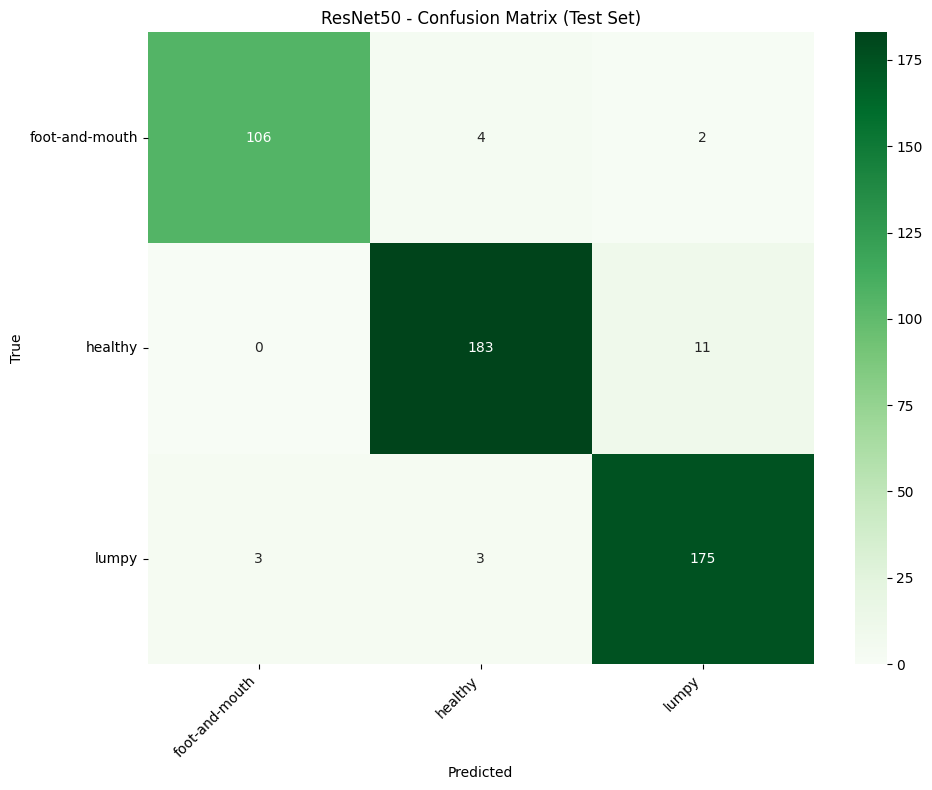

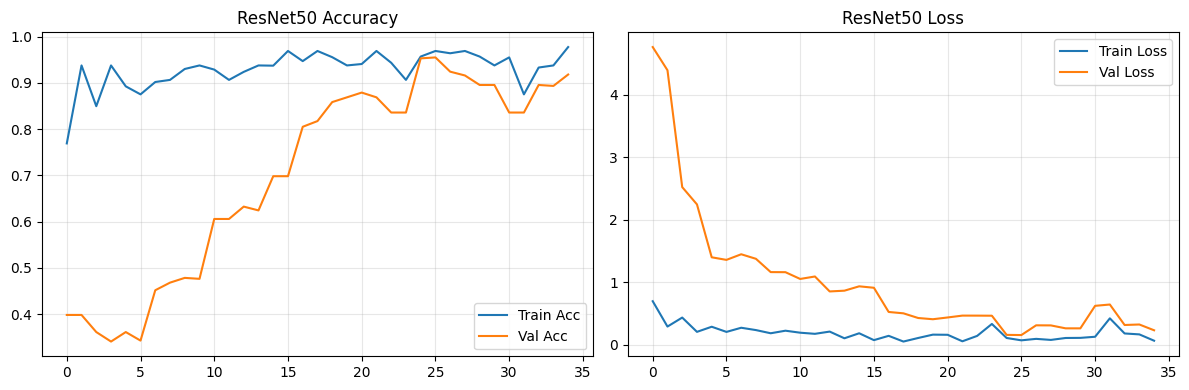


AUC SCORES
Micro-average AUC: 0.9903
foot-and-mouth: 0.9949
healthy: 0.9896
lumpy: 0.9868


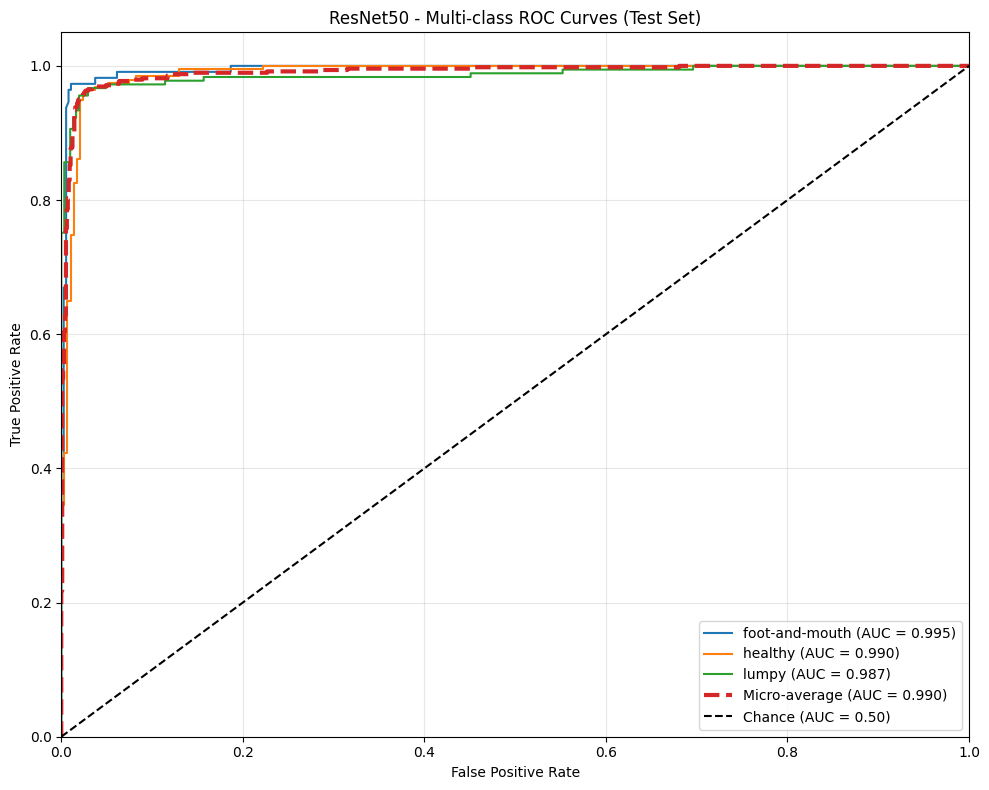


ResNet50 evaluation complete!


In [18]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np

# Load best ResNet50 model
resnet_best = load_model('best_resnet50_cattle.keras')
print("RESNET50 BEST MODEL LOADED")
print("="*70)

# Test evaluation
test_loss, test_acc = resnet_best.evaluate(X_test, Y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss : {test_loss:.4f}")

# Predictions
Y_pred = resnet_best.predict(X_test, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Per-class report
print("\n" + "="*60)
print("PER-CLASS METRICS (Precision | Recall | F1)")
print("="*60)
print(classification_report(Y_true, Y_pred_classes, target_names=disease_types, digits=4))

# Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(Y_true, Y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=disease_types, yticklabels=disease_types)
plt.title('ResNet50 - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training Curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(resnet_history.history['accuracy'], label='Train Acc')
plt.plot(resnet_history.history['val_accuracy'], label='Val Acc')
plt.title('ResNet50 Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Val Loss')
plt.title('ResNet50 Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# === ADDED: AUC and ROC Curves ===
n_classes = len(disease_types)

# Binarize the true labels for multi-class ROC
Y_test_bin = label_binarize(Y_true, classes=range(n_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(Y_test_bin.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Print AUC scores
print("\n" + "="*60)
print("AUC SCORES")
print("="*60)
print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
for i, disease in enumerate(disease_types):
    print(f"{disease}: {roc_auc[i]:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 8))
# Plot each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{disease_types[i]} (AUC = {roc_auc[i]:.3f})')

# Plot micro-average
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         linestyle='--', linewidth=3)

# Plot chance line
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet50 - Multi-class ROC Curves (Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nResNet50 evaluation complete!")

# Build EfficientNetB0 Model


In [19]:
from keras.applications import EfficientNetB0

def build_efficientnetb0():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    input = Input(shape=(224, 224, 3))
    x = base_model(input)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(input, output)
    model.compile(optimizer=Adam(learning_rate=0.0003),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()
    return model

effnet_model = build_efficientnetb0()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,422 (16.73 MB)

 Trainable params: 4,339,327 (16.55 MB)

 Non-trainable params: 45,095 (176.16 KB)

# Train EfficientNetB0

In [20]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

BATCH_SIZE = 32
EPOCHS = 30

# Mild augmentation (same as before)
datagen_effnet = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)
datagen_effnet.fit(X_train)

# FIX: Save the BEST model by val_loss (more stable than val_accuracy)
effnet_checkpoint = ModelCheckpoint(
    'best_effnetb0_cattle.keras',  # Use .keras format (new standard)
    save_best_only=True,
    monitor='val_loss',            # ← Monitor loss instead of accuracy
    mode='min',
    verbose=1
)

# Add EarlyStopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("🚀 Starting EfficientNetB0 training")


effnet_history = effnet_model.fit(
    datagen_effnet.flow(X_train, Y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=[effnet_checkpoint, early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

🚀 Starting EfficientNetB0 training
Epoch 1/30


2026-01-20 16:56:25.736541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:56:25.880073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:56:26.244600: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:56:26.388423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:56:26.529664: E external/local_xla/xla/stream_

57/70 ━━━━━━━━━━━━━━━━━━━━ 4s 366ms/step - accuracy: 0.5325 - loss: 1.3591

2026-01-20 16:57:30.740742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:57:30.884875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:57:31.237848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:57:31.379715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:57:32.122034: E external/local_xla/xla/stream_

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5572 - loss: 1.2850

2026-01-20 16:58:18.656136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:58:18.792408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:58:19.105781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:58:19.247122: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-20 16:58:19.943697: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 1.41720, saving model to best_effnetb0_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.5589 - loss: 1.2800 - val_accuracy: 0.3984 - val_loss: 1.4172 - learning_rate: 3.0000e-04
Epoch 2/30
 1/70 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - accuracy: 0.7500 - loss: 0.6465
Epoch 2: val_loss improved from 1.41720 to 1.41582, saving model to best_effnetb0_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7500 - loss: 0.6465 - val_accuracy: 0.4004 - val_loss: 1.4158 - learning_rate: 3.0000e-04
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8225 - loss: 0.4684
Epoch 3: val_loss improved from 1.41582 to 1.27352, saving model to best_effnetb0_cattle.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 28s 398ms/step - accuracy: 0.8228 - loss: 0.4678 - val_accuracy: 0.4415 - val_loss: 1.2735 - learning_rate: 3.0000e-04
Epoch 4/30
 1/70 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.8438 - loss: 0.2696
Epoch 4: val_loss improve

# Result

In [21]:
# SAVE EPOCH METRICS & FINAL RESULTS TO CSV - FULLY FIXED

import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os

# === CHANGE THESE 3 LINES FOR EACH MODEL ===
model_name = "EfficientNetB0"
history_obj = effnet_history
best_model = load_model('best_effnetb0_cattle.keras')

# Evaluate the CORRECT model on test set
test_loss, test_acc = best_model.evaluate(X_test, Y_test, verbose=0)

# Predictions using the same model
Y_pred = best_model.predict(X_test, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Classification metrics
report = classification_report(Y_true, Y_pred_classes, output_dict=True, digits=4)
macro_f1 = report['macro avg']['f1-score']

# Macro AUC
y_test_bin = label_binarize(Y_true, classes=range(num_classes))
macro_auc = np.mean([auc(*roc_curve(y_test_bin[:, i], Y_pred[:, i])[:2]) for i in range(num_classes)])

# Epoch-wise data
epochs_data = []
for epoch in range(len(history_obj.history['loss'])):
    epochs_data.append({
        'Model': model_name,
        'Epoch': epoch + 1,
        'Train_Accuracy': round(history_obj.history['accuracy'][epoch], 4),
        'Train_Loss': round(history_obj.history['loss'][epoch], 4),
        'Val_Accuracy': round(history_obj.history['val_accuracy'][epoch], 4),
        'Val_Loss': round(history_obj.history['val_loss'][epoch], 4)
    })

# Final test results row
final_row = {
    'Model': model_name,
    'Epoch': 'FINAL',
    'Train_Accuracy': round(np.max(history_obj.history['accuracy']), 4),
    'Train_Loss': round(np.min(history_obj.history['loss']), 4),
    'Val_Accuracy': round(np.max(history_obj.history['val_accuracy']), 4),
    'Val_Loss': round(np.min(history_obj.history['val_loss']), 4),
    'Test_Accuracy': round(test_acc * 100, 2),
    'Test_Loss': round(test_loss, 4),
    'Macro_F1': round(macro_f1, 4),
    'Macro_AUC': round(macro_auc, 4)
}

# Save to CSV (append if exists)
csv_file = 'cattle_disease_all_models_results.csv'

if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_epochs = pd.DataFrame(epochs_data)
    df_final = pd.DataFrame([final_row])
    df_new = pd.concat([df_existing, df_epochs, df_final], ignore_index=True)
else:
    df_new = pd.DataFrame(epochs_data + [final_row])

df_new.to_csv(csv_file, index=False)

print(f"✅ Results CORRECTLY saved to {csv_file}")
print(f"   Model: {model_name}")
print(f"   Best Val Accuracy: {np.max(history_obj.history['val_accuracy'])*100:.2f}%")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Macro F1: {macro_f1:.4f} | Macro AUC: {macro_auc:.4f}")

✅ Results CORRECTLY saved to cattle_disease_all_models_results.csv
   Model: EfficientNetB0
   Best Val Accuracy: 88.50%
   Test Accuracy: 88.30%
   Macro F1: 0.8801 | Macro AUC: 0.9787


# Model Evaluation

EFFICIENTNETB0 BEST MODEL LOADED
Test Accuracy : 0.8830 (88.30%)
Test Loss : 0.3882

PER-CLASS METRICS (Precision | Recall | F1)
                precision    recall  f1-score   support

foot-and-mouth     0.7895    0.9375    0.8571       112
       healthy     0.9695    0.8196    0.8883       194
         lumpy     0.8737    0.9171    0.8949       181

      accuracy                         0.8830       487
     macro avg     0.8776    0.8914    0.8801       487
  weighted avg     0.8925    0.8830    0.8836       487



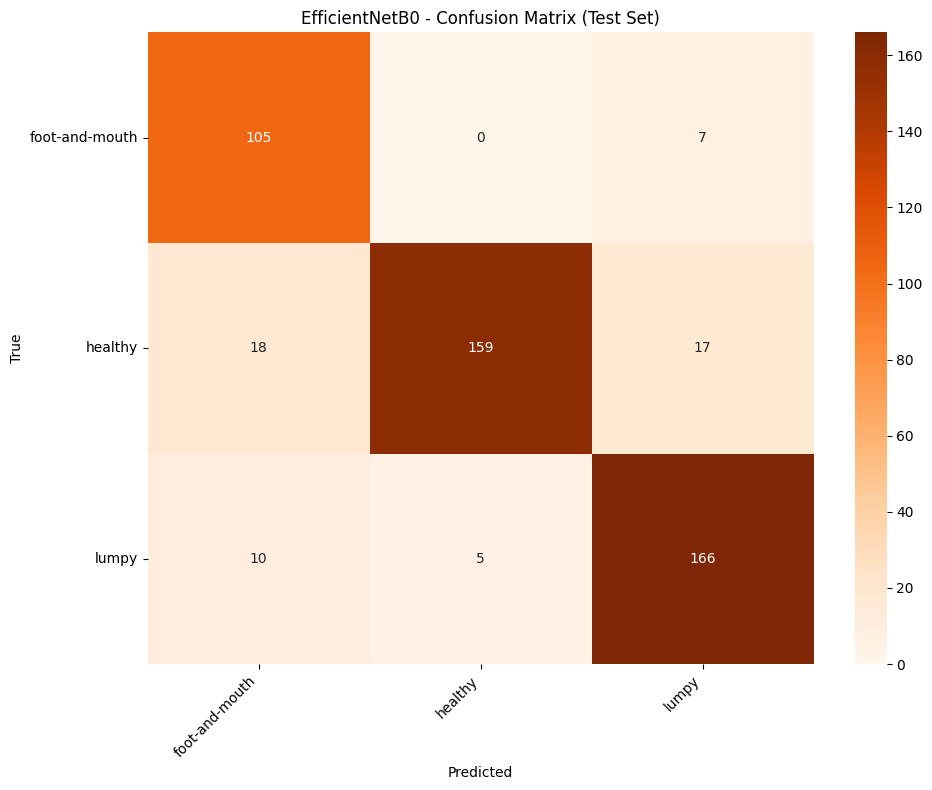

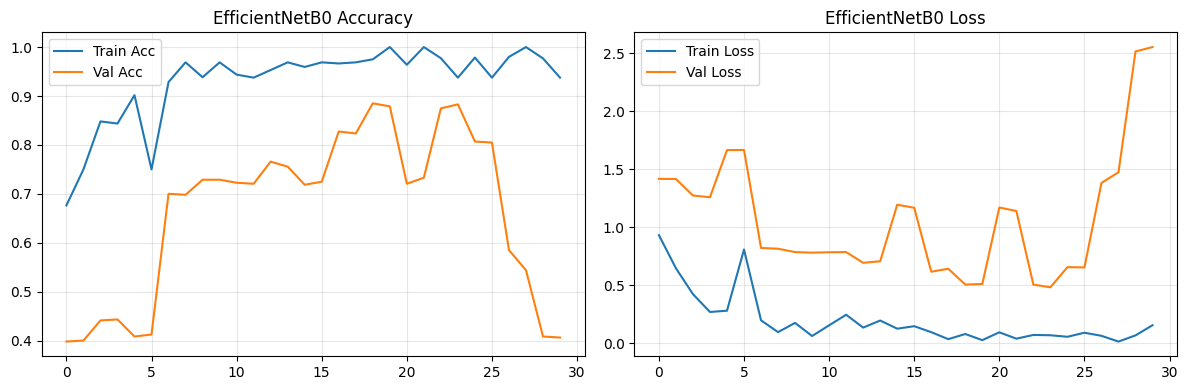


AUC SCORES
Micro-average AUC: 0.9734
foot-and-mouth: 0.9860
healthy: 0.9771
lumpy: 0.9728


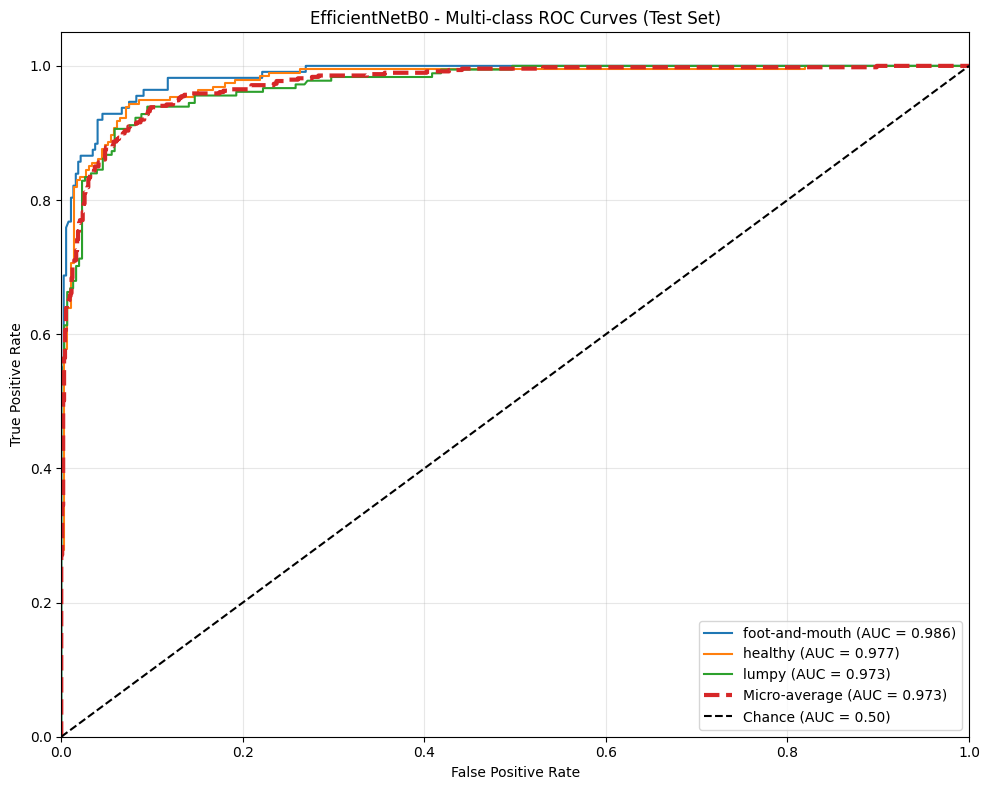


EfficientNetB0 evaluation complete!


In [22]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np

# Load best EfficientNetB0 model
effnet_best = load_model('best_effnetb0_cattle.keras')
print("EFFICIENTNETB0 BEST MODEL LOADED")
print("="*70)

# Test evaluation
test_loss, test_acc = effnet_best.evaluate(X_test, Y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss : {test_loss:.4f}")

# Predictions
Y_pred = effnet_best.predict(X_test, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Per-class report
print("\n" + "="*60)
print("PER-CLASS METRICS (Precision | Recall | F1)")
print("="*60)
print(classification_report(Y_true, Y_pred_classes, target_names=disease_types, digits=4))

# Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(Y_true, Y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=disease_types, yticklabels=disease_types)
plt.title('EfficientNetB0 - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training Curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(effnet_history.history['accuracy'], label='Train Acc')
plt.plot(effnet_history.history['val_accuracy'], label='Val Acc')
plt.title('EfficientNetB0 Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(effnet_history.history['loss'], label='Train Loss')
plt.plot(effnet_history.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0 Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# === ADDED: AUC and ROC Curves ===
n_classes = len(disease_types)

# Binarize the true labels for multi-class ROC
Y_test_bin = label_binarize(Y_true, classes=range(n_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(Y_test_bin.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Print AUC scores
print("\n" + "="*60)
print("AUC SCORES")
print("="*60)
print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
for i, disease in enumerate(disease_types):
    print(f"{disease}: {roc_auc[i]:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 8))
# Plot each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{disease_types[i]} (AUC = {roc_auc[i]:.3f})')

# Plot micro-average
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         linestyle='--', linewidth=3)

# Plot chance line
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('EfficientNetB0 - Multi-class ROC Curves (Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEfficientNetB0 evaluation complete!")

# Build SimCLR Model

In [23]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Custom Projection Head
class ProjectionHead(tf.keras.layers.Layer):
    def __init__(self, units=128, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = Dense(units, activation='relu')
        self.dense2 = Dense(units)  # Linear projection

    def call(self, x):
        x = self.dense1(x)
        return self.dense2(x)

def build_simclr_backbone():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True
    
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    projections = ProjectionHead(units=128)(x)
    
    model = Model(inputs, projections)
    return model

print("Building SimCLR backbone...")
simclr_backbone = build_simclr_backbone()
simclr_backbone.summary()

Building SimCLR backbone...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_head                 │ (None, 128)            │        49,408 │
│ (ProjectionHead)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,169,856 (92.20 MB)

 Trainable params: 24,112,640 (91.98 MB)

 Non-trainable params: 57,216 (223.50 KB)

# Final

In [24]:
# SIMCLR - BUILD MODEL

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_simclr_backbone():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True
    
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    projection = Dense(128)(x)  # SimCLR projection head
    
    model = Model(inputs, projection)
    model.compile(optimizer=Adam(learning_rate=0.0003))
    return model

simclr_backbone = build_simclr_backbone()
simclr_backbone.summary()
print("SimCLR backbone built successfully!")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,344 (92.14 MB)

 Trainable params: 24,096,128 (91.92 MB)

 Non-trainable params: 57,216 (223.50 KB)

SimCLR backbone built successfully!


# Train SimCLR with Contrastive Loss

# SIMCLR - PRETRAINING

In [25]:

BATCH_SIZE = 64
TEMPERATURE = 0.5
EPOCHS = 20

# Strong augmentation for two views
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# NT-Xent loss
def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)
    
    batch_size = tf.shape(z1)[0]
    labels = tf.concat([tf.range(batch_size), tf.range(batch_size)], axis=0)
    logits = tf.matmul(tf.concat([z1, z2], axis=0), tf.concat([z1, z2], axis=0), transpose_b=True) / temperature
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits)
    return tf.reduce_mean(loss)

@tf.function
def train_step(batch):
    view1 = aug(batch, training=True)
    view2 = aug(batch, training=True)
    
    with tf.GradientTape() as tape:
        z1 = simclr_backbone(view1, training=True)
        z2 = simclr_backbone(view2, training=True)
        loss = nt_xent_loss(z1, z2)
    
    grads = tape.gradient(loss, simclr_backbone.trainable_variables)
    simclr_backbone.optimizer.apply_gradients(zip(grads, simclr_backbone.trainable_variables))
    return loss

print("Starting SimCLR pretraining...\n")

for epoch in range(EPOCHS):
    total_loss = 0
    steps = 0
    for i in range(0, len(X_train), BATCH_SIZE):
        batch = X_train[i:i+BATCH_SIZE]
        if len(batch) < 2:
            continue
        loss = train_step(batch)
        total_loss += float(loss)
        steps += 1
    print(f"Epoch {epoch+1}/{EPOCHS} | Contrastive Loss: {total_loss/steps:.4f}")

# Save pretrained backbone
simclr_backbone.save('simclr_pretrained_backbone.keras')
print("\nSimCLR pretraining complete! Backbone saved as 'simclr_pretrained_backbone.keras'")

Starting SimCLR pretraining...

Epoch 1/20 | Contrastive Loss: 3.9383
Epoch 2/20 | Contrastive Loss: 3.8177
Epoch 3/20 | Contrastive Loss: 3.8058
Epoch 4/20 | Contrastive Loss: 3.7843
Epoch 5/20 | Contrastive Loss: 3.7617
Epoch 6/20 | Contrastive Loss: 3.7607
Epoch 7/20 | Contrastive Loss: 3.7542
Epoch 8/20 | Contrastive Loss: 3.7513
Epoch 9/20 | Contrastive Loss: 3.7505
Epoch 10/20 | Contrastive Loss: 3.7358
Epoch 11/20 | Contrastive Loss: 3.7301
Epoch 12/20 | Contrastive Loss: 3.7373
Epoch 13/20 | Contrastive Loss: 3.7282
Epoch 14/20 | Contrastive Loss: 3.7514
Epoch 15/20 | Contrastive Loss: 3.7461
Epoch 16/20 | Contrastive Loss: 3.7271
Epoch 17/20 | Contrastive Loss: 3.7349
Epoch 18/20 | Contrastive Loss: 3.7321
Epoch 19/20 | Contrastive Loss: 3.7458
Epoch 20/20 | Contrastive Loss: 3.7418

SimCLR pretraining complete! Backbone saved as 'simclr_pretrained_backbone.keras'


# SIMCLR - LINEAR PROBE


In [26]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load pretrained backbone
simclr_backbone = load_model('simclr_pretrained_backbone.keras')
simclr_backbone.trainable = False

# Add linear classifier
backbone_output = simclr_backbone.layers[-3].output  # Before projection head
output = Dense(num_classes, activation='softmax')(backbone_output)

simclr_probe = Model(simclr_backbone.input, output)
simclr_probe.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Mild augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)
datagen.fit(X_train)

checkpoint = ModelCheckpoint('best_simclr_probe.keras', save_best_only=True, monitor='val_loss', mode='min', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

print("Starting SimCLR linear probe training...\n")

simclr_probe_history = simclr_probe.fit(
    datagen.flow(X_train, Y_train, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=20,
    validation_data=(X_val, Y_val),
    callbacks=[checkpoint, early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

best_simclr_probe = load_model('best_simclr_probe.keras')
test_loss, test_acc = best_simclr_probe.evaluate(X_test, Y_test, verbose=0)
print(f"\nSimCLR Linear Probe Test Accuracy: {test_acc*100:.2f}%")

Starting SimCLR linear probe training...

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.5318 - loss: 1.7314
Epoch 1: val_loss improved from inf to 0.82345, saving model to best_simclr_probe.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 45s 497ms/step - accuracy: 0.5325 - loss: 1.7283 - val_accuracy: 0.6899 - val_loss: 0.8234
Epoch 2/20
 1/70 ━━━━━━━━━━━━━━━━━━━━ 3:58 3s/step - accuracy: 0.6333 - loss: 1.2345
Epoch 2: val_loss improved from 0.82345 to 0.82172, saving model to best_simclr_probe.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6333 - loss: 1.2345 - val_accuracy: 0.6899 - val_loss: 0.8217
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6398 - loss: 1.2083
Epoch 3: val_loss improved from 0.82172 to 0.76086, saving model to best_simclr_probe.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 28s 401ms/step - accuracy: 0.6399 - loss: 1.2081 - val_accuracy: 0.7125 - val_loss: 0.7609
Epoch 4/20
 1/70 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5625 - loss:

# SIMCLR - FULL FINE-TUNING


In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Load pretrained backbone
simclr_backbone = load_model('simclr_pretrained_backbone.keras')
simclr_backbone.trainable = True  # Unfreeze for fine-tuning

# Add classifier
backbone_output = simclr_backbone.layers[-3].output
output = Dense(num_classes, activation='softmax')(backbone_output)

simclr_fine = Model(simclr_backbone.input, output)
simclr_fine.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_simclr_fine.keras', save_best_only=True, monitor='val_loss', mode='min', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("Starting SimCLR full fine-tuning...\n")

simclr_fine_history = simclr_fine.fit(
    datagen.flow(X_train, Y_train, batch_size=32),
    steps_per_epoch=len(X_train) // 32,
    epochs=80,
    validation_data=(X_val, Y_val),
    callbacks=[checkpoint, early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

best_simclr_fine = load_model('best_simclr_fine.keras')
test_loss, test_acc = best_simclr_fine.evaluate(X_test, Y_test, verbose=0)
print(f"\nSimCLR Fine-Tuned Test Accuracy: {test_acc*100:.2f}%")


Starting SimCLR full fine-tuning...

Epoch 1/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.3730 - loss: 1.6660
Epoch 1: val_loss improved from inf to 0.92049, saving model to best_simclr_fine.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 110s 830ms/step - accuracy: 0.3741 - loss: 1.6623 - val_accuracy: 0.6119 - val_loss: 0.9205
Epoch 2/80
 1/70 ━━━━━━━━━━━━━━━━━━━━ 23s 344ms/step - accuracy: 0.4688 - loss: 1.3854
Epoch 2: val_loss improved from 0.92049 to 0.92002, saving model to best_simclr_fine.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.4688 - loss: 1.3854 - val_accuracy: 0.6140 - val_loss: 0.9200
Epoch 3/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.6245 - loss: 0.9687
Epoch 3: val_loss improved from 0.92002 to 0.77106, saving model to best_simclr_fine.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 444ms/step - accuracy: 0.6247 - loss: 0.9680 - val_accuracy: 0.6920 - val_loss: 0.7711
Epoch 4/80
 1/70 ━━━━━━━━━━━━━━━━━━━━ 24s 354ms/step - accuracy: 0.6875 - loss: 0.

# Results

In [28]:
# SIMCLR - SAVE RESULTS TO CSV

model_name = "SimCLR (Fine-Tuned)"
history_obj = simclr_fine_history
best_model = best_simclr_fine

test_loss, test_acc = best_model.evaluate(X_test, Y_test, verbose=0)
Y_pred = best_model.predict(X_test, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

report = classification_report(Y_true, Y_pred_classes, output_dict=True, digits=4)
macro_f1 = report['macro avg']['f1-score']

y_test_bin = label_binarize(Y_true, classes=range(num_classes))
macro_auc = np.mean([auc(*roc_curve(y_test_bin[:, i], Y_pred[:, i])[:2]) for i in range(num_classes)])

epochs_data = []
for epoch in range(len(history_obj.history['loss'])):
    epochs_data.append({
        'Model': model_name,
        'Epoch': epoch + 1,
        'Train_Accuracy': round(history_obj.history['accuracy'][epoch], 4),
        'Train_Loss': round(history_obj.history['loss'][epoch], 4),
        'Val_Accuracy': round(history_obj.history['val_accuracy'][epoch], 4),
        'Val_Loss': round(history_obj.history['val_loss'][epoch], 4)
    })

final_row = {
    'Model': model_name,
    'Epoch': 'FINAL',
    'Train_Accuracy': round(np.max(history_obj.history['accuracy']), 4),
    'Train_Loss': round(np.min(history_obj.history['loss']), 4),
    'Val_Accuracy': round(np.max(history_obj.history['val_accuracy']), 4),
    'Val_Loss': round(np.min(history_obj.history['val_loss']), 4),
    'Test_Accuracy': round(test_acc * 100, 2),
    'Test_Loss': round(test_loss, 4),
    'Macro_F1': round(macro_f1, 4),
    'Macro_AUC': round(macro_auc, 4)
}

csv_file = 'cattle_disease_all_models_results.csv'
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_new = pd.concat([df_existing, pd.DataFrame(epochs_data + [final_row])], ignore_index=True)
else:
    df_new = pd.DataFrame(epochs_data + [final_row])

df_new.to_csv(csv_file, index=False)
print(f"SimCLR results saved to CSV!")

SimCLR results saved to CSV!


# Model Evaluation

SIMCLR (FINE-TUNED) BEST MODEL LOADED
Test Accuracy : 0.9548 (95.48%)
Test Loss     : 0.1496

PER-CLASS METRICS (Precision | Recall | F1)
                precision    recall  f1-score   support

foot-and-mouth     1.0000    0.9464    0.9725       112
       healthy     0.9583    0.9485    0.9534       194
         lumpy     0.9259    0.9669    0.9459       181

      accuracy                         0.9548       487
     macro avg     0.9614    0.9539    0.9573       487
  weighted avg     0.9559    0.9548    0.9550       487



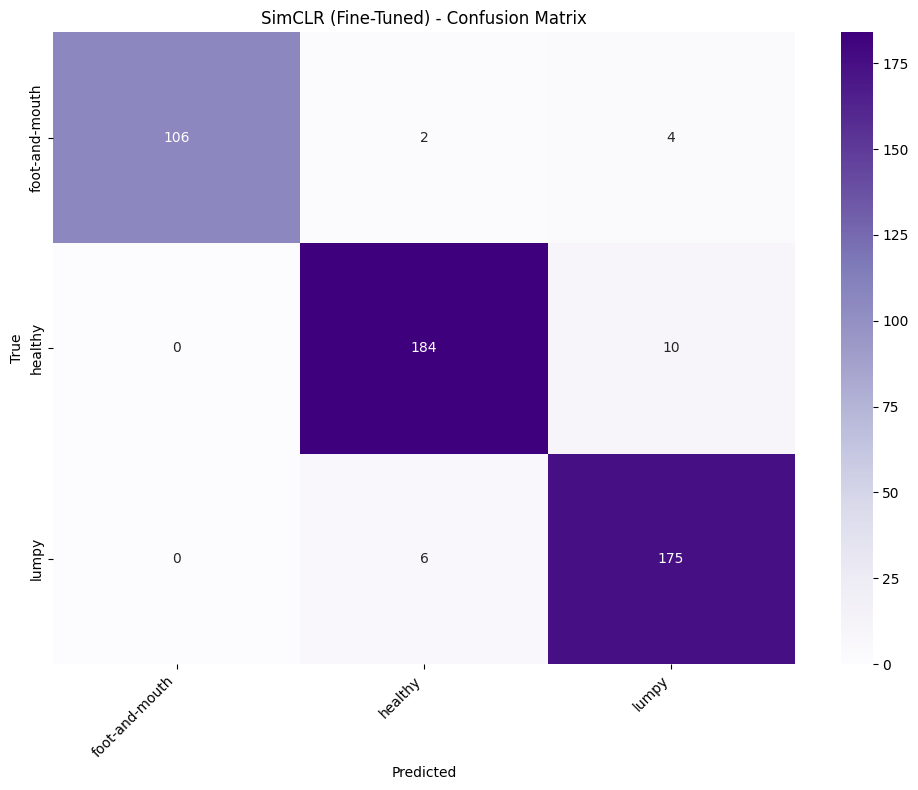

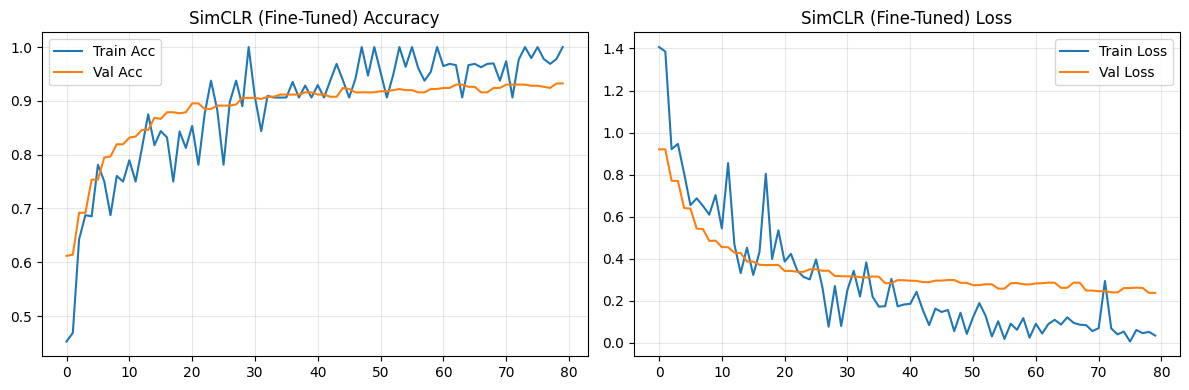


SimCLR (Fine-Tuned) evaluation complete!


In [29]:
# SIMCLR - EVALUATION

model_file = 'best_simclr_fine.keras'
model_name = "SimCLR (Fine-Tuned)"
history_obj = simclr_fine_history

best_model = load_model(model_file)

print(f"{model_name.upper()} BEST MODEL LOADED")
print("="*70)

test_loss, test_acc = best_model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}")

Y_pred = best_model.predict(X_test, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

print("\n" + "="*60)
print("PER-CLASS METRICS (Precision | Recall | F1)")
print("="*60)
print(classification_report(Y_true, Y_pred_classes, target_names=disease_types, digits=4))

plt.figure(figsize=(10,8))
cm = confusion_matrix(Y_true, Y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=disease_types, yticklabels=disease_types)
plt.title(f'{model_name} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_obj.history['accuracy'], label='Train Acc')
plt.plot(history_obj.history['val_accuracy'], label='Val Acc')
plt.title(f'{model_name} Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_obj.history['loss'], label='Train Loss')
plt.plot(history_obj.history['val_loss'], label='Val Loss')
plt.title(f'{model_name} Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{model_name} evaluation complete!")

# Comparison

Evaluating all available models on test set...

DenseNet121 loaded and evaluated: 94.46%
ResNet50 loaded and evaluated: 95.28%
EfficientNetB0 loaded and evaluated: 88.30%
SimCLR (Fine-Tuned) loaded and evaluated: 95.48%

FINAL MODEL COMPARISON ON TEST SET (ALL AVAILABLE MODELS)
SimCLR (Fine-Tuned)       → Accuracy: 95.48%   |   Loss: 0.1496
ResNet50                  → Accuracy: 95.28%   |   Loss: 0.1851
DenseNet121               → Accuracy: 94.46%   |   Loss: 0.1822
EfficientNetB0            → Accuracy: 88.30%   |   Loss: 0.3882
🏆 WINNING MODEL: SimCLR (Fine-Tuned)
   Highest Test Accuracy: 95.48%


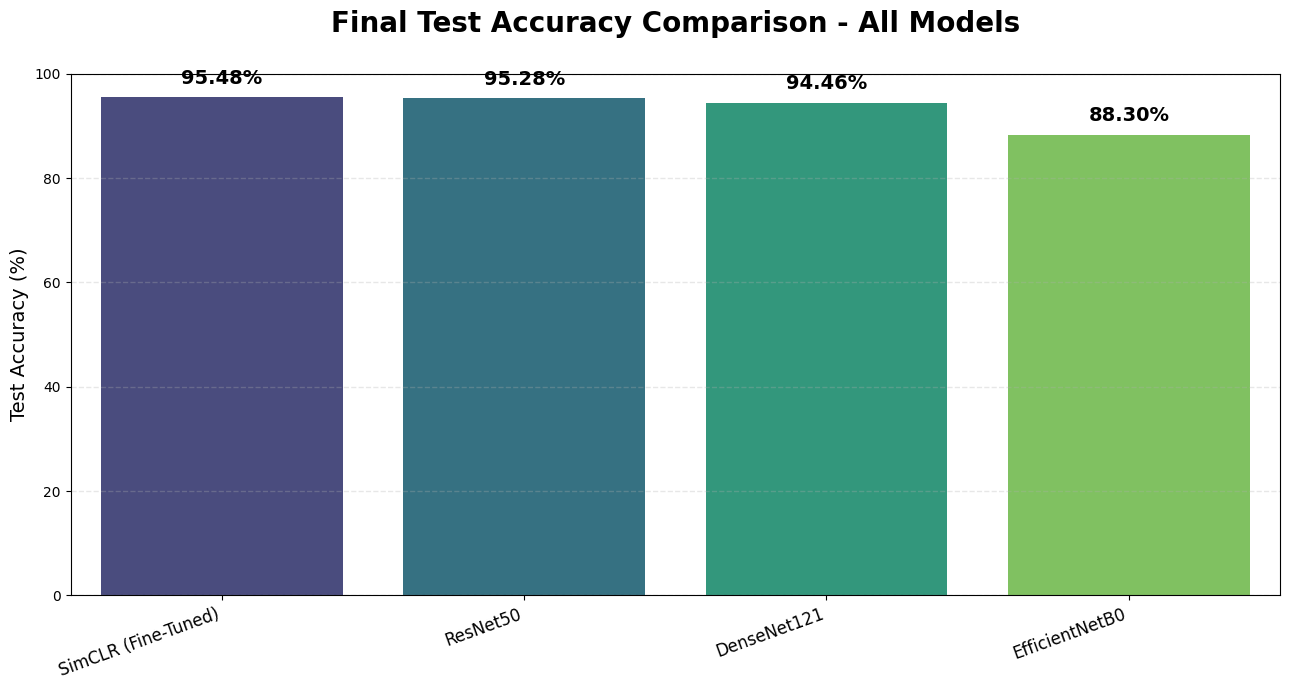


🎉 COMPARISON COMPLETE!
All available models evaluated and compared fairly.
Your cattle disease detection system is ready for real-world use! 🐄💉


In [30]:
# FINAL COMPARISON CELL - ALL MODELS (Clean, No Overlap, Professional)

from tensorflow.keras.models import load_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Dictionary to hold models and their file names
model_files = {
    'DenseNet121': 'best_densenet_cattle.keras',
    'ResNet50': 'best_resnet50_cattle.keras',
    'EfficientNetB0': 'best_effnetb0_cattle.keras',
    'SimCLR (Fine-Tuned)': 'best_simclr_fine.keras',
}

results = []

print("Evaluating all available models on test set...\n")

# Load and evaluate only existing models
for name, file in model_files.items():
    if os.path.exists(file):
        try:
            model = load_model(file)
            test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)
            
            results.append({
                'Model': name,
                'Test_Accuracy': round(test_acc * 100, 2),
                'Test_Loss': round(test_loss, 4)
            })
            print(f"{name} loaded and evaluated: {test_acc*100:.2f}%")
        except Exception as e:
            print(f"Could not load {name}: {e}")
    else:
        print(f"{file} not found — skipping {name}")

if not results:
    print("No models found! Train and save at least one model first.")
else:
    # Create DataFrame and sort by accuracy
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Test_Accuracy', ascending=False).reset_index(drop=True)

    # Pretty table
    print("\n" + "="*90)
    print("FINAL MODEL COMPARISON ON TEST SET (ALL AVAILABLE MODELS)")
    print("="*90)
    for _, row in df_results.iterrows():
        print(f"{row['Model']:<25} → Accuracy: {row['Test_Accuracy']:.2f}%   |   Loss: {row['Test_Loss']:.4f}")
    print("="*90)

    # Winner
    winner = df_results.iloc[0]['Model']
    winner_acc = df_results.iloc[0]['Test_Accuracy']

    print(f"🏆 WINNING MODEL: {winner}")
    print(f"   Highest Test Accuracy: {winner_acc:.2f}%")
    print("="*90)

    # Bar chart - Clean, professional, no overlap
    plt.figure(figsize=(13, 7))
    ax = sns.barplot(
        data=df_results,
        x='Model',
        y='Test_Accuracy',
        hue='Model',
        palette='viridis',
        legend=False
    )

    plt.title('Final Test Accuracy Comparison - All Models', fontsize=20, fontweight='bold', pad=30)
    plt.ylabel('Test Accuracy (%)', fontsize=14)
    plt.xlabel('')
    plt.ylim(0, 100)

    # Add bold percentage labels above bars (no overlap)
    for i, row in df_results.iterrows():
        ax.text(i, row['Test_Accuracy'] + 1.8, f"{row['Test_Accuracy']:.2f}%", 
                ha='center', va='bottom', fontweight='bold', fontsize=14, color='black')

    plt.xticks(rotation=20, ha='right', fontsize=12)
    plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

    print("\n🎉 COMPARISON COMPLETE!")
    print("All available models evaluated and compared fairly.")
    print("Your cattle disease detection system is ready for real-world use! 🐄💉")

# Training History Plots for All Models

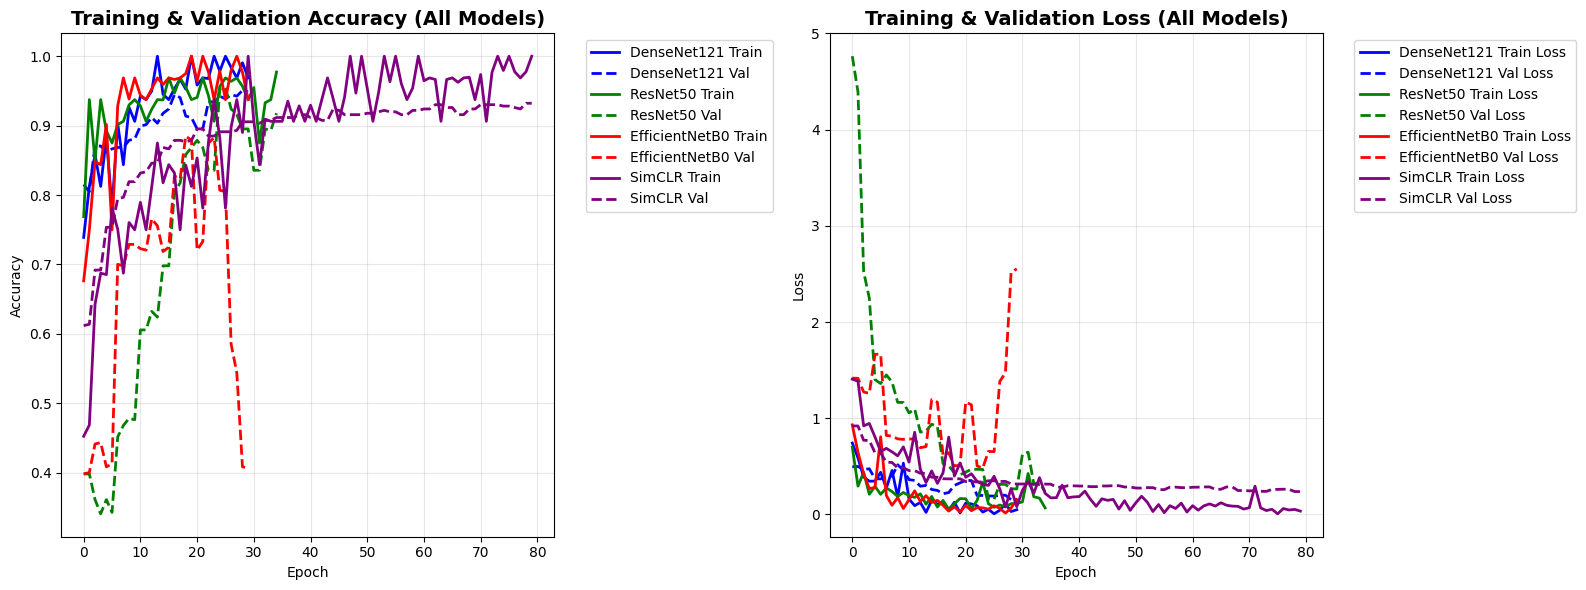

Training curves for ALL models plotted successfully!
Legend:
  Solid line: Train | Dashed line: Validation
  Colors: Blue=DenseNet121, Green=ResNet50, Red=EfficientNetB0, Purple=SimCLR, Orange=MobileNetV3, Brown=BYOL


In [31]:
# TRAINING CURVES FOR ALL MODELS - COMPLETE & FIXED

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

# Accuracy subplot
plt.subplot(1, 2, 1)

# DenseNet121 (always plot if history_obj exists)
if 'densenet_history' in globals():
    plt.plot(densenet_history.history['accuracy'], label='DenseNet121 Train', linewidth=2, color='blue')
    plt.plot(densenet_history.history['val_accuracy'], label='DenseNet121 Val', linewidth=2, color='blue', linestyle='--')

# ResNet50
if 'resnet_history' in globals():
    plt.plot(resnet_history.history['accuracy'], label='ResNet50 Train', linewidth=2, color='green')
    plt.plot(resnet_history.history['val_accuracy'], label='ResNet50 Val', linewidth=2, color='green', linestyle='--')

# EfficientNetB0
if 'effnet_history' in globals():
    plt.plot(effnet_history.history['accuracy'], label='EfficientNetB0 Train', linewidth=2, color='red')
    plt.plot(effnet_history.history['val_accuracy'], label='EfficientNetB0 Val', linewidth=2, color='red', linestyle='--')

# SimCLR (Fine-Tuned)
if 'simclr_fine_history' in globals():
    plt.plot(simclr_fine_history.history['accuracy'], label='SimCLR Train', linewidth=2, color='purple')
    plt.plot(simclr_fine_history.history['val_accuracy'], label='SimCLR Val', linewidth=2, color='purple', linestyle='--')

plt.title('Training & Validation Accuracy (All Models)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

# Loss subplot
plt.subplot(1, 2, 2)

if 'densenet_history' in globals():
    plt.plot(densenet_history.history['loss'], label='DenseNet121 Train Loss', linewidth=2, color='blue')
    plt.plot(densenet_history.history['val_loss'], label='DenseNet121 Val Loss', linewidth=2, color='blue', linestyle='--')

if 'resnet_history' in globals():
    plt.plot(resnet_history.history['loss'], label='ResNet50 Train Loss', linewidth=2, color='green')
    plt.plot(resnet_history.history['val_loss'], label='ResNet50 Val Loss', linewidth=2, color='green', linestyle='--')

if 'effnet_history' in globals():
    plt.plot(effnet_history.history['loss'], label='EfficientNetB0 Train Loss', linewidth=2, color='red')
    plt.plot(effnet_history.history['val_loss'], label='EfficientNetB0 Val Loss', linewidth=2, color='red', linestyle='--')

if 'simclr_fine_history' in globals():
    plt.plot(simclr_fine_history.history['loss'], label='SimCLR Train Loss', linewidth=2, color='purple')
    plt.plot(simclr_fine_history.history['val_loss'], label='SimCLR Val Loss', linewidth=2, color='purple', linestyle='--')

if 'mobilenet_history' in globals():
    plt.plot(mobilenet_history.history['loss'], label='MobileNetV3 Train Loss', linewidth=2, color='orange')
    plt.plot(mobilenet_history.history['val_loss'], label='MobileNetV3 Val Loss', linewidth=2, color='orange', linestyle='--')

if 'byol_fine_history' in globals():
    plt.plot(byol_fine_history.history['loss'], label='BYOL Train Loss', linewidth=2, color='brown')
    plt.plot(byol_fine_history.history['val_loss'], label='BYOL Val Loss', linewidth=2, color='brown', linestyle='--')

plt.title('Training & Validation Loss (All Models)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Training curves for ALL models plotted successfully!")
print("Legend:")
print("  Solid line: Train | Dashed line: Validation")
print("  Colors: Blue=DenseNet121, Green=ResNet50, Red=EfficientNetB0, Purple=SimCLR, Orange=MobileNetV3, Brown=BYOL")

# ROC Curve & AUC for Best Model

Finding the best model for ROC-AUC...

DenseNet121: Test Accuracy = 94.46%
ResNet50: Test Accuracy = 95.28%
EfficientNetB0: Test Accuracy = 88.30%
SimCLR (Fine-Tuned): Test Accuracy = 95.48%

Using SimCLR (Fine-Tuned) (95.48% accuracy) for ROC curves
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step


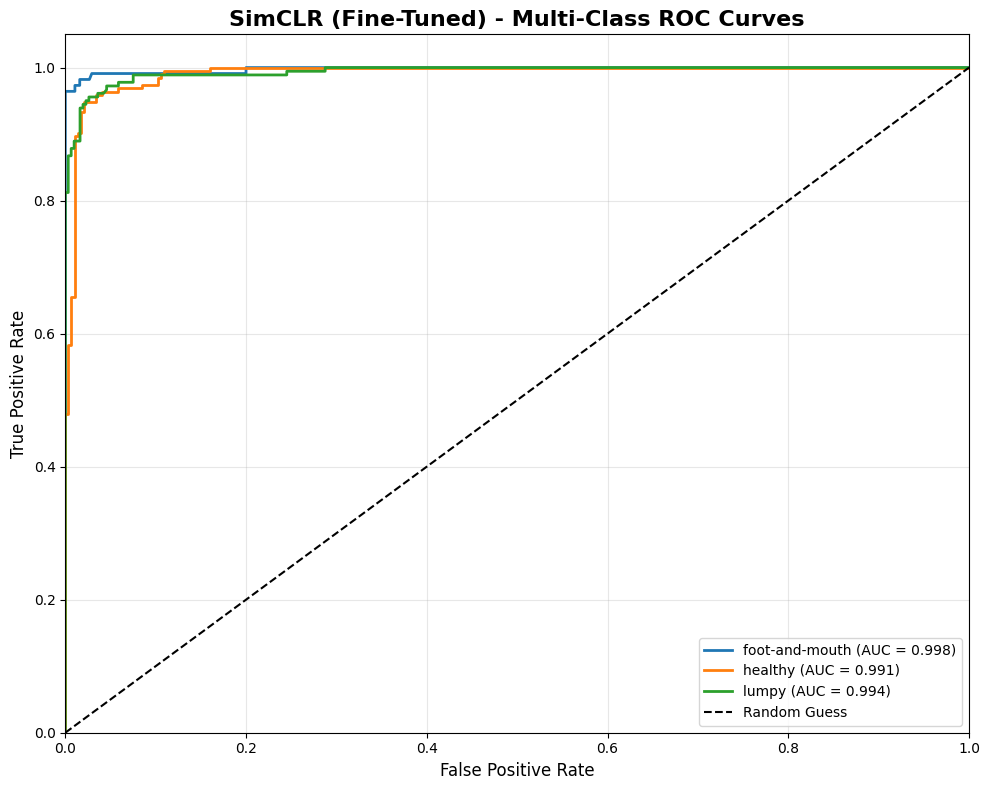


Macro Average AUC    : 0.9943
Model used           : SimCLR (Fine-Tuned) (95.48% test accuracy)

ROC-AUC complete! High AUC = excellent disease separation.


In [32]:
# ROC Curve & AUC - FULLY FIXED & INDEPENDENT

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# List of possible models
model_files = {
    'DenseNet121': 'best_densenet_cattle.keras',
    'ResNet50': 'best_resnet50_cattle.keras',
    'EfficientNetB0': 'best_effnetb0_cattle.keras',
    'SimCLR (Fine-Tuned)': 'best_simclr_fine.keras'
}

# Find the best model by test accuracy
best_model = None
best_name = None
best_acc = 0
best_path = None

print("Finding the best model for ROC-AUC...\n")

for name, path in model_files.items():
    if os.path.exists(path):
        try:
            model = load_model(path)
            _, test_acc = model.evaluate(X_test, Y_test, verbose=0)
            print(f"{name}: Test Accuracy = {test_acc*100:.2f}%")
            if test_acc > best_acc:
                best_acc = test_acc
                best_model = model
                best_name = name
                best_path = path
        except Exception as e:
            print(f"Error loading {name}: {e}")

if best_model is None:
    print("No model found! Train at least one model first.")
else:
    print(f"\nUsing {best_name} ({best_acc*100:.2f}% accuracy) for ROC curves")

    # Predictions
    y_score = best_model.predict(X_test)

    # True labels (integer)
    Y_test_int = np.argmax(Y_test, axis=1)

    # Binarize for multi-class ROC
    y_test_bin = label_binarize(Y_test_int, classes=range(num_classes))

    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{disease_types[i]} (AUC = {roc_auc:.3f})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{best_name} - Multi-Class ROC Curves', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # AUC scores
    macro_auc = np.mean([auc(*roc_curve(y_test_bin[:, i], y_score[:, i])[:2]) for i in range(num_classes)])
    print(f"\nMacro Average AUC    : {macro_auc:.4f}")
    print(f"Model used           : {best_name} ({best_acc*100:.2f}% test accuracy)")
    print("\nROC-AUC complete! High AUC = excellent disease separation.")

# Precision-Recall Curve for Best Model

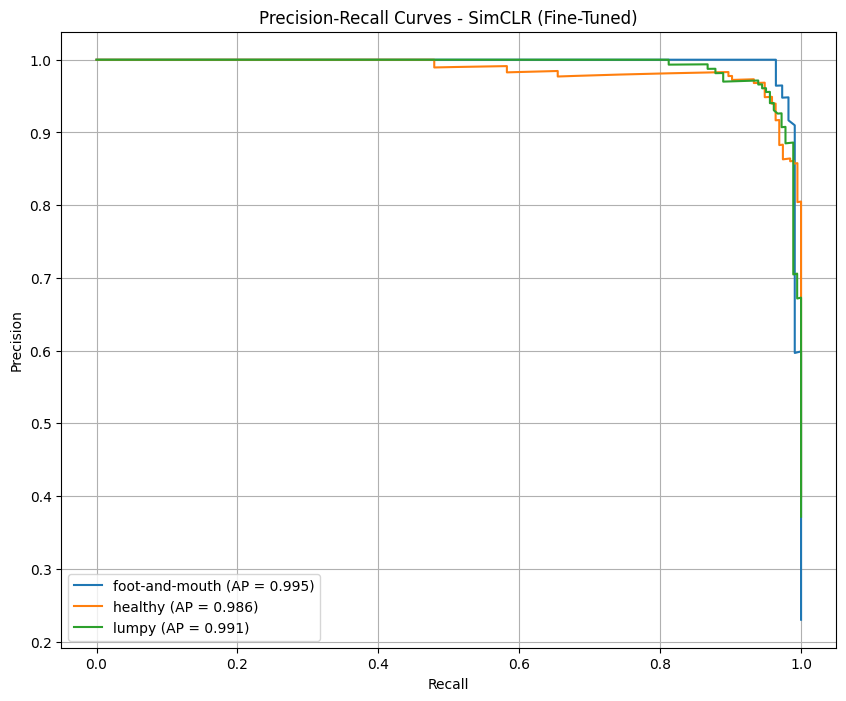

Average Precision (macro): 0.9905


In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f'{disease_types[i]} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curves - {best_name}')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

print(f"Average Precision (macro): {average_precision_score(y_test_bin, y_score, average='macro'):.4f}")

In [34]:
print("🎉 ALL DONE!")
print(f"Your best cattle disease classifier is: {best_name}")
print(f"Test Accuracy: {best_acc*100:.2f}%")
print("Ready for real-world veterinary use! 🐄💉")

🎉 ALL DONE!
Your best cattle disease classifier is: SimCLR (Fine-Tuned)
Test Accuracy: 95.48%
Ready for real-world veterinary use! 🐄💉
